In [70]:
##The work is incomplete. the final version will be submitted by Saturday.

# Day 5 — Matplotlib & Week 1 Mini-Notebook

## Step 1

In [71]:
import pandas as pd
import numpy as np
df = pd.read_csv("train.csv")

In [72]:
missing = df.isnull().sum()

print(missing)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [73]:
df_new = df.drop(columns=["Cabin"])
print(df_new)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [74]:
x = df_new["Age"].median()
print("Average age:", x)
df_new["Age"]= df_new["Age"].fillna(x)
print(df_new)

Average age: 28.0
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 

In [75]:
df_new = df_new.dropna(subset=["Embarked"])
print(df_new)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [76]:
zero_fare= df_new[df_new["Fare"] == 0]
print("Zero fare passengers:", len(zero_fare))

Zero fare passengers: 15


In [77]:
 mean_with_zero = df["Fare"].mean()
 print("The mean including 0 Fares:", mean_with_zero)
 mean = df.loc[df["Fare"]>0, "Fare"].mean()
 print("The mean excluding 0 Fares:",mean)

The mean including 0 Fares: 32.204207968574636
The mean excluding 0 Fares: 32.75564988584475


## Step 2:

In [78]:
sibsp = df_new["SibSp"].to_numpy()
parch = df_new["Parch"].to_numpy()
age = df_new["Age"].to_numpy()
fare = df_new["Fare"].to_numpy()

family = sibsp + parch + 1
df_new["family_size"] = family

x = df_new["family_size"]
print(x)
 

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 889, dtype: int64


In [79]:
age_group = np.where(age<18, "Child", np.where(age<20,"Teen", np.where( age<60, "Adult","Senior")))
df_new["age_group"] = age_group
df_new["age_group"].value_counts()

age_group
Adult     700
Child     113
Teen       51
Senior     25
Name: count, dtype: int64

In [80]:
mean_age = np.mean(age)
median_age = np.median(age)
std_age = np.std(age)

print("Mean age:", mean_age)
print("Median age:", median_age)
print("Standard deviation of age:", std_age)

Mean age: 29.315151856017994
Median age: 28.0
Standard deviation of age: 12.977627127265219


In [81]:
fare_25 = np.percentile(fare, 25)
fare_75 = np.percentile(fare,75)

iqr = fare_75 - fare_25

print("25th percentile Fare:", fare_25)
print("75th percentile Fare:", fare_75)
print("Interquartile Range:", iqr)

25th percentile Fare: 7.8958
75th percentile Fare: 31.0
Interquartile Range: 23.1042


In [82]:
print("Minimum Fare:", np.min(fare))
print("Maximum Fare:", np.max(fare))

Minimum Fare: 0.0
Maximum Fare: 512.3292


## Step 3:

In [83]:
import matplotlib.pyplot as plt

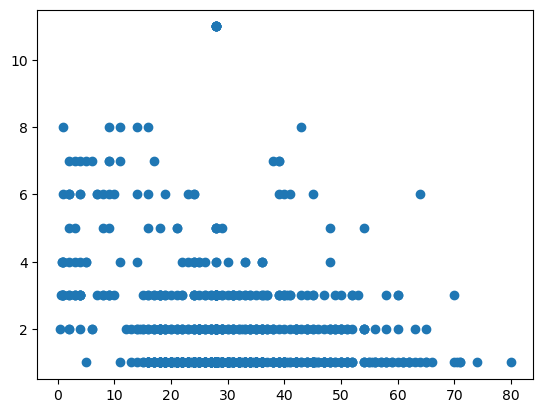

In [84]:
x = np.array(age)
y = np.array(family)

plt.scatter(x,y)
plt.colorbar
plt.show()

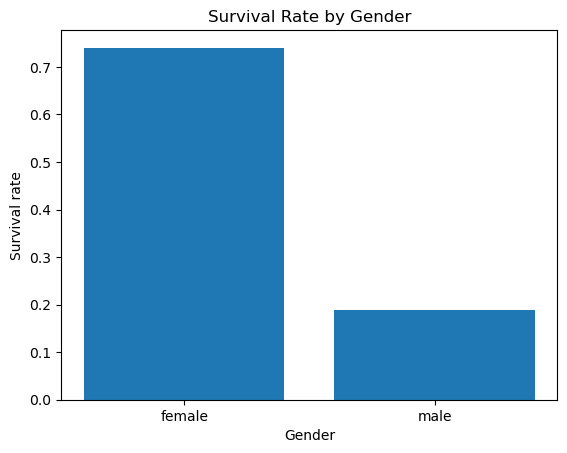

In [85]:
gender_based_survival = df_new.groupby("Sex")["Survived"].mean() 
plt.bar(gender_based_survival.index, gender_based_survival.values)
plt.xlabel("Gender")
plt.ylabel("Survival rate")
plt.title("Survival Rate by Gender")
plt.show()

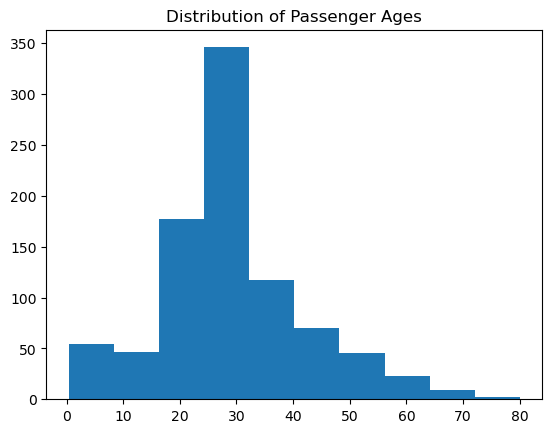

In [86]:
plt.hist(age)
plt.title("Distribution of Passenger Ages")
plt.show()

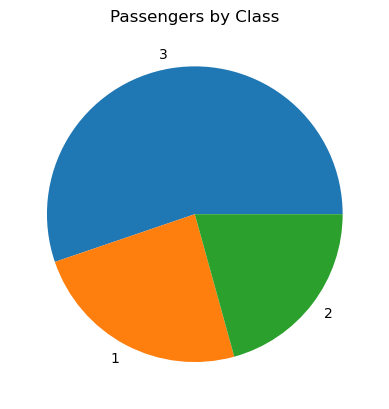

In [87]:
mylabels = ["3", "1", "2"]
plt.pie(df_new["Pclass"].value_counts(), labels=mylabels)
plt.title("Passengers by Class")
plt.show()

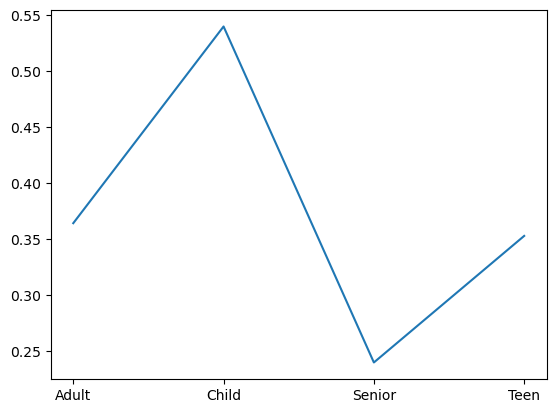

In [69]:
order = ["Child", "Teen", "Adult", "Senior"]
survival_byage = df_new.groupby("age_group")["Survived"].mean()
plt.plot( survival_byage.index, survival_byage.values)
plt.show()

In [ ]:
##The work is incomplete. the final version will be submitted by Saturday.